<a href="https://colab.research.google.com/github/shivnarayan007/Shivnarayan.V/blob/master/IDS%20Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
import numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import KNNImputer


In [82]:
df = pd.read_csv("train.csv", header = 'infer')
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0,1


In [83]:
len(df)

2000

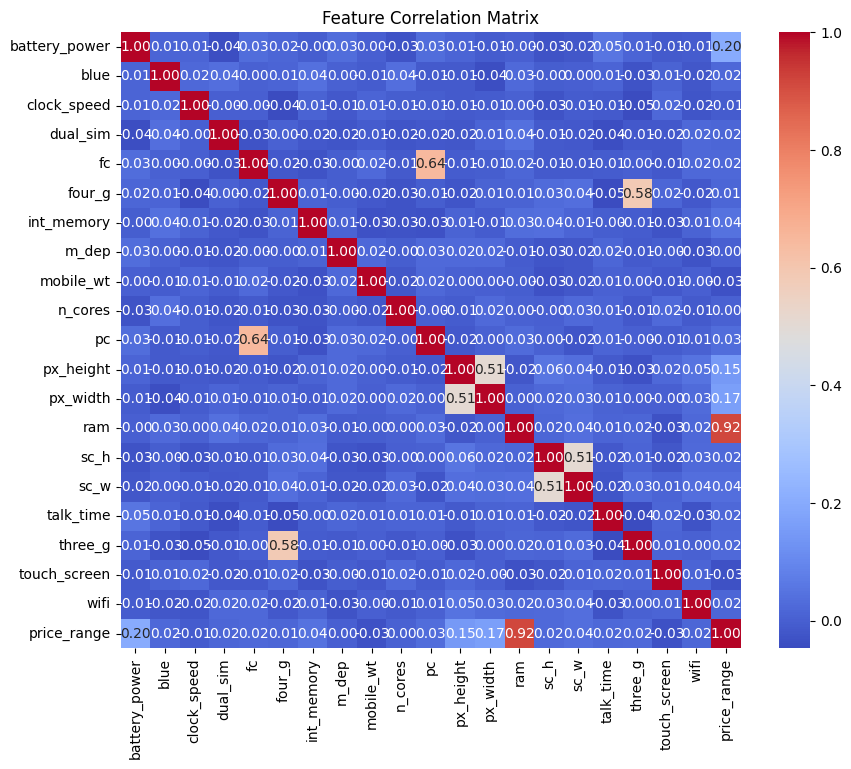

In [108]:
df.corr()

correlation_matrix = df.corr(method = 'pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

In [110]:
target_correlation = df.corr()['price_range'].drop('price_range')
target_correlation

,price_range
battery_power,0.200723
blue,0.020573
clock_speed,-0.006606
dual_sim,0.017444
fc,0.021998
four_g,0.014772
int_memory,0.044435
m_dep,0.000853
mobile_wt,-0.030302
n_cores,0.004399


In [85]:
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [86]:
target_column = df.columns[-1]
target_column

'price_range'

In [87]:
df[target_column]

,price_range
0,1
1,2
2,2
3,2
4,1
...,...
1995,0
1996,2
1997,3
1998,0


In [88]:
type(df)

pandas.core.frame.DataFrame

In [89]:
j = 0
for i in df:
  j += 1
  print (type(i))
print(j)

<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
21


In [90]:
df[:2]

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0,2


In [91]:
df.isna().sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


In [92]:
df['battery_power'] = df['battery_power'].fillna(df['battery_power'].mean())
df['battery_power']

df['clock_speed'] = df['clock_speed'].fillna(df['clock_speed'].mean())
df['clock_speed']

df['fc'] = df['fc'].fillna(df['fc'].mean())
df['fc']

df['int_memory'] = df['int_memory'].fillna(df['int_memory'].mean())
df['m_dep']= df['m_dep'].fillna(df['m_dep'].mean())
df['mobile_wt'] = df['mobile_wt'].fillna(df['mobile_wt'].mean())
df['n_cores'] = df['n_cores'].fillna(df['n_cores'].mode())
df['pc'] = df['pc'].fillna(df['pc'].median())
df['px_height'] = df['px_height'].fillna(df['px_height'].mean())
df['px_width'] = df['px_width'].fillna(df['px_width'].mean())
df['ram'] = df['ram'].fillna(df['ram'].mean())
df['sc_h'] = df['sc_h'].fillna(df['sc_h'].mean())
df['sc_w'] = df['sc_w'].fillna(df['sc_w'].mean())
df['talk_time'] = df['talk_time'].fillna(df['talk_time'].median())


In [93]:
df['blue'] = df['blue'].fillna(method='ffill')
df['blue']

df['dual_sim'] = df['dual_sim'].fillna(method='ffill')
df['dual_sim']

df['four_g'] = df['four_g'].fillna(method = 'ffill')
df['four_g']
df['price_range']= df['price_range'].fillna(method = 'ffill')
df['three_g']= df['three_g'].fillna(method = 'ffill')
df['touch_screen']= df['touch_screen'].fillna(method = 'ffill')
df['wifi']= df['wifi'].fillna(method = 'ffill')

/tmp/ipykernel_412/2864002264.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['blue'] = df['blue'].fillna(method='ffill')
/tmp/ipykernel_412/2864002264.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['dual_sim'] = df['dual_sim'].fillna(method='ffill')
/tmp/ipykernel_412/2864002264.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['four_g'] = df['four_g'].fillna(method = 'ffill')
/tmp/ipykernel_412/2864002264.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['price_range']= df['price_range'].fillna(method = 'ffill')
/tmp/ipykernel_412/2864002264.py:10: FutureWarning: Series.fillna with 'method' is deprecated and w

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64
price_range
1    0.25
2    0.25
3    0.25
0    0.25
Name: proportion, dtype: float64


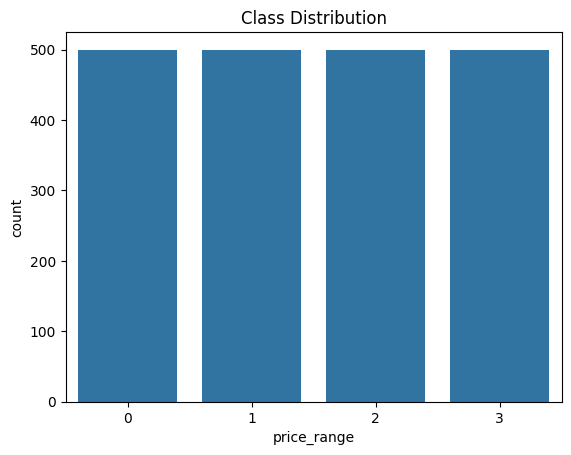

<Axes: title={'center': 'Class Distribution'}, ylabel='count'>

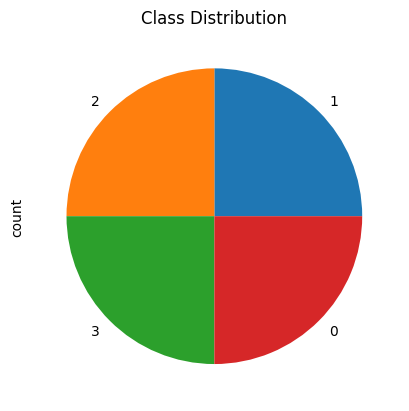

In [94]:
# Class Imbalance Ratio


print(df['price_range'].value_counts())

print(df['price_range'].value_counts(normalize=True))

sns.countplot(x='price_range', data=df)
plt.title('Class Distribution')
plt.show()
df['price_range'].value_counts().plot(kind='pie', title='Class Distribution')


In [95]:
# Outliers Handling

columns = ['battery_power','clock_speed','int_memory','mobile_wt','px_height','px_width','ram']

for i in columns:
  q1 = df[i].quantile(0.25)
  q3 = df[i].quantile(0.75)
  interQuantileRange = q3 - q1

  lowestElement = q1 - (1.5 * interQuantileRange)
  highestElement = q3 + (1.5 * interQuantileRange)

  df[i] = numpy.where(
    (df[i] < lowestElement) | (df[i] > highestElement),
    numpy.nan,
    df[i]
  )

#KNN Imputer predicts the missing values based on surrounding context
imputer = KNNImputer(n_neighbors=3)
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

In [96]:
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842.0,0.0,2.2,0.0,1.0,0.0,7.0,0.6,188.0,2.0,2.0,20.0,756.0,2549.0,9.0,7.0,19.0,0.0,0.0,1.0,1.0
1,1021.0,1.0,0.5,1.0,0.0,1.0,53.0,0.7,136.0,3.0,6.0,905.0,1988.0,2631.0,17.0,3.0,7.0,1.0,1.0,0.0,2.0
2,563.0,1.0,0.5,1.0,2.0,1.0,41.0,0.9,145.0,5.0,6.0,1263.0,1716.0,2603.0,11.0,2.0,9.0,1.0,1.0,0.0,2.0
3,615.0,1.0,2.5,0.0,0.0,0.0,10.0,0.8,131.0,6.0,9.0,1216.0,1786.0,2769.0,16.0,8.0,11.0,1.0,0.0,0.0,2.0
4,1821.0,1.0,1.2,0.0,13.0,1.0,44.0,0.6,141.0,2.0,14.0,1208.0,1212.0,1411.0,8.0,2.0,15.0,1.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794.0,1.0,0.5,1.0,0.0,1.0,2.0,0.8,106.0,6.0,14.0,1222.0,1890.0,668.0,13.0,4.0,19.0,1.0,1.0,0.0,0.0
1996,1965.0,1.0,2.6,1.0,0.0,0.0,39.0,0.2,187.0,4.0,3.0,915.0,1965.0,2032.0,11.0,10.0,16.0,1.0,1.0,1.0,2.0
1997,1911.0,0.0,0.9,1.0,1.0,1.0,36.0,0.7,108.0,8.0,3.0,868.0,1632.0,3057.0,9.0,1.0,5.0,1.0,1.0,0.0,3.0
1998,1512.0,0.0,0.9,0.0,4.0,1.0,46.0,0.1,145.0,5.0,5.0,336.0,670.0,869.0,18.0,10.0,19.0,1.0,1.0,1.0,0.0


Text(2.2, 1, 'blue=1')

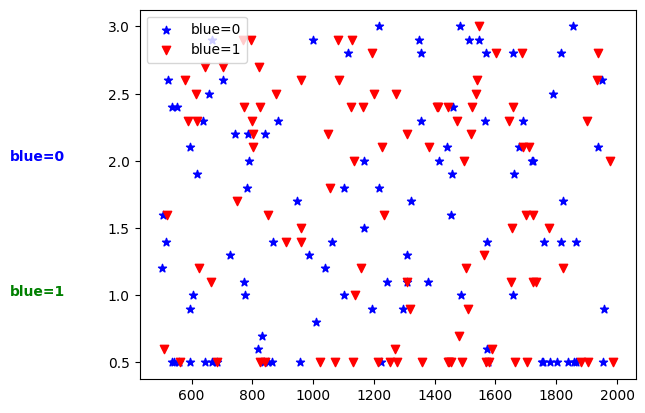

In [97]:
# Scatter plot
df1=df[df['blue']==0][:100]
df2=df[df['blue']==1][:100]

plt.scatter(df1['battery_power'],df1['clock_speed'],color='blue', marker= '*', label='blue=0')
plt.scatter(df2['battery_power'],df2['clock_speed'],color= 'red', marker='v', label='blue=1')
plt.legend()

plt.text(2.5+0.2, 2, "blue=0", horizontalalignment='left', size='medium', color='blue', weight='semibold')
plt.text(2+0.2, 1, "blue=1", horizontalalignment='left', size='medium', color='green', weight='semibold')


Text(2.2, 1, 'touch_screen=1')

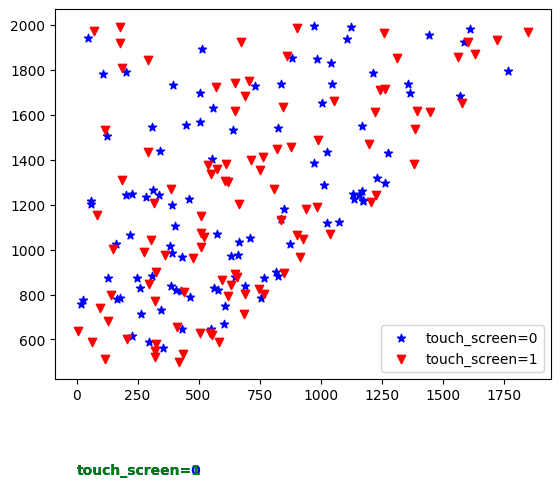

In [98]:
# Scatter plot 2
df1=df[df['touch_screen']==0][:100]
df2=df[df['touch_screen']==1][:100]

plt.scatter(df1['px_height'],df1['px_width'],color='blue', marker= '*', label='touch_screen=0')
plt.scatter(df2['px_height'],df2['px_width'],color= 'red', marker='v', label='touch_screen=1')
plt.legend()

plt.text(2.5+0.2, 2, "touch_screen=0", horizontalalignment='left', size='medium', color='blue', weight='semibold')
plt.text(2+0.2, 1, "touch_screen=1", horizontalalignment='left', size='medium', color='green', weight='semibold')


/tmp/ipykernel_412/890069291.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = i, data = df, palette="coolwarm_r")
/tmp/ipykernel_412/890069291.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = i, data = df, palette="coolwarm_r")
/tmp/ipykernel_412/890069291.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = i, data = df, palette="coolwarm_r")


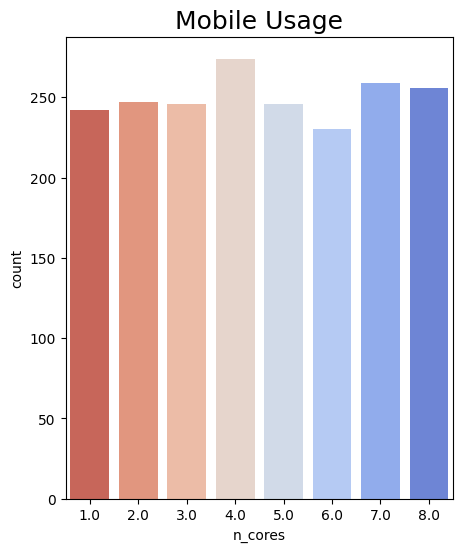

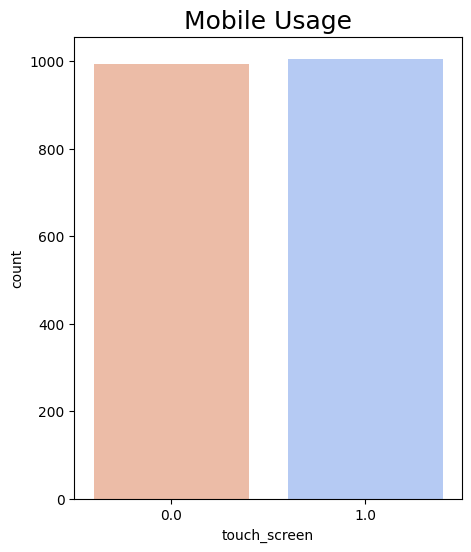

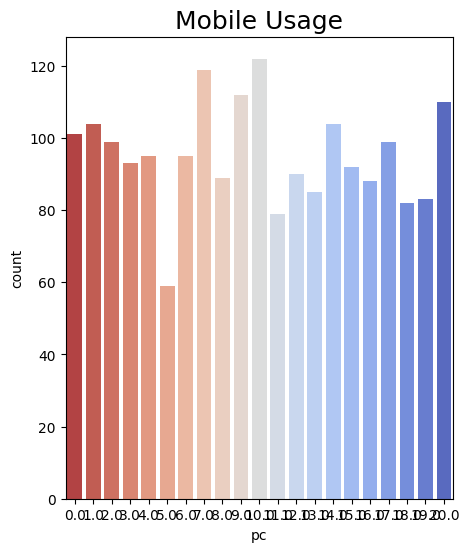

In [104]:
# CountPlots
columns_countplot = ['n_cores','touch_screen','pc']
for i in columns_countplot:
  plt.figure(figsize=(5,6))
  ax = sns.countplot(x = i, data = df, palette="coolwarm_r")
  plt.title('Mobile Usage', fontsize=18)

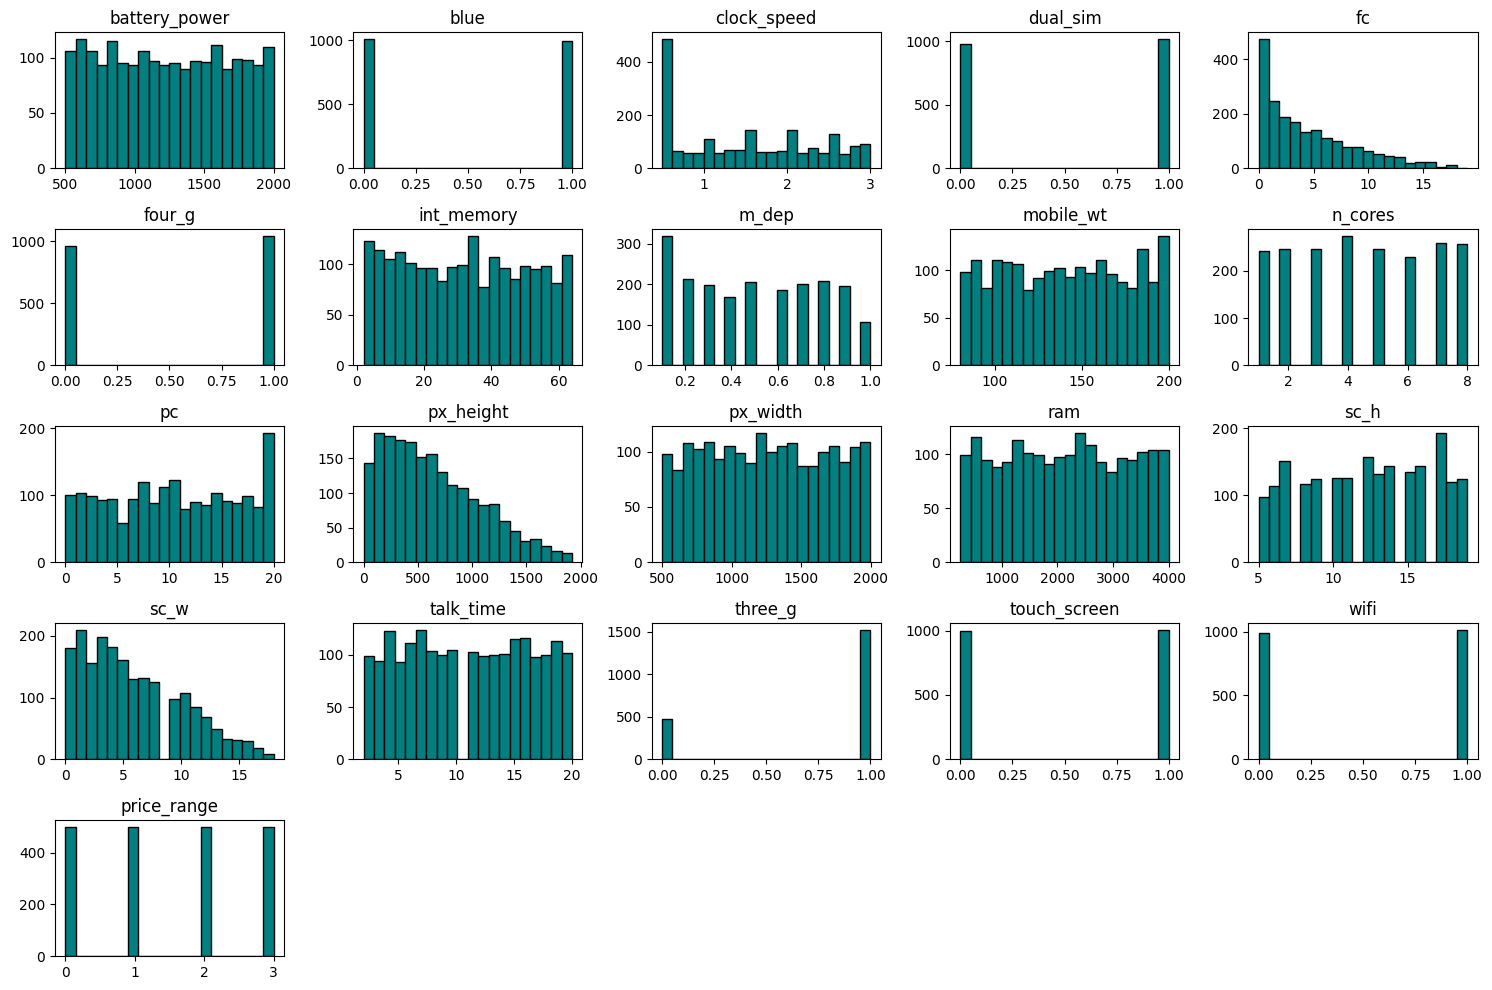

In [105]:
df.hist(bins=20, figsize=(15, 10), grid=False, edgecolor='black', color='teal')
plt.tight_layout()
plt.show()

In [107]:
description = df.describe()
description

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,9.916500,643.558167,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,6.064315,441.931070,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,0.000000,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,5.000000,282.000000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,10.000000,563.500000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,15.000000,945.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,20.000000,1920.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [100]:
# Data Pipeline creation
# Using Basic SKLEARN PIPELINE

class DataExtractor(BaseEstimator, TransformerMixin):
  def __init__(self, source_dir):
    self.source_dir = source_dir

  def fit(self, X=None, y=None):
    return self

  def transform(self, X=None):
    df = pd.read_csv("train.csv", header = 'infer')
    print(df.head())
    return df


In [101]:
class DataIngestor(BaseEstimator, TransformerMixin):
  def __init__(self, target_column: str):
    self.target_column = target_column

  def fit(self, X, y=None):
    return self

  def transform(self, X: pd.DataFrame) -> pd.DataFrame:
    assert self.target_column in X.columns, \
        f"Target '{self.target_column}' not in columns: {X.columns.tolist()}"
    return X

In [102]:
class DataCleaner(BaseEstimator, TransformerMixin):
  def transform(self, X: pd.DataFrame) -> pd.DataFrame:
    df_cleaned = X.copy
    print(X.isna().sum())
    df_cleaned.drop_duplicates(inplace=True)
    df_cleaned.dropna(axis = 1, inplace = True)
